Data collecting from three datasets

In [1]:
import pandas as pd

# Load multiple datasets
df1 = pd.read_csv('datasets/fake_job_postings.csv', low_memory=False)
df2 = pd.read_csv('datasets/Fake Postings.csv', low_memory=False)
df3 = pd.read_csv('datasets/job_train.csv', low_memory=False)
df4 = pd.read_csv('datasets/fake_job_postings1.csv', low_memory=False)
df5 = pd.read_csv('datasets/Fake_Jobs_Postings.csv', low_memory=False)
df6 = pd.read_csv('datasets/fake_job_postings2.csv', low_memory=False)
# Align column names
common_cols = list(set(df1.columns) & set(df2.columns) & set(df3.columns) & set(df4.columns) & set(df5.columns) & set(df6.columns))
df1, df2, df3, df4, df5, df6 = [df[common_cols] for df in [df1, df2, df3, df4, df5, df6]]

# Merge all datasets
df_combined = pd.concat([df1, df2, df3, df4, df5, df6], axis=0).drop_duplicates().reset_index(drop=True)

# Check merged shape and label balance
print("Total rows:", len(df_combined))
print(df_combined['fraudulent'].value_counts())


Total rows: 27457
fraudulent
0    16631
1    10826
Name: count, dtype: int64


In [9]:
import re
import numpy as np

df = df_combined.copy()

# Normalize target labels
label_map = {
    'f': 0, 'F': 0, 'false': 0, 'False': 0, 'FALSE': 0, False: 0, 0: 0, '0': 0,
    't': 1, 'T': 1, 'true': 1, 'True': 1, 'TRUE': 1, True: 1, 1: 1, '1': 1
}
df['fraudulent'] = df['fraudulent'].map(label_map).astype('Int64')

before = len(df)
df = df.dropna(subset=['fraudulent'])
df['fraudulent'] = df['fraudulent'].astype(int)
print(f"Dropped rows with invalid labels: {before - len(df)}")

possible_cols = [
    'title','company_profile','description','requirements','benefits',
    'industry','employment_type','required_experience','required_education',
    'function','location','telecommuting','has_company_logo','has_questions'
]
existing = [c for c in possible_cols if c in df.columns]
missing = [c for c in possible_cols if c not in df.columns]
print("Using columns:", existing)
if missing:
    print("Missing columns (ok to miss):", missing)

dup_keys = [c for c in ['title','description'] if c in df.columns]
if dup_keys:
    before = len(df)
    df = df.drop_duplicates(subset=dup_keys)
    print(f"Removed potential duplicates based on {dup_keys}: {before - len(df)}")

for c in ['title','company_profile','description','requirements','benefits','industry','employment_type','function','location']:
    if c not in df.columns:
        df[c] = ""

df[existing] = df[existing].fillna("")
df['text_raw'] = (
    df.get('title','') + " " + df.get('company_profile','') + " " + df.get('description','') + " " +
    df.get('requirements','') + " " + df.get('benefits','') + " " + df.get('industry','') + " " +
    df.get('employment_type','') + " " + df.get('function','') + " " + df.get('location','')
).astype(str)

# Text cleaning
_url = re.compile(r'(http[s]?://\S+|www\.\S+)')
_email = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w{2,}\b')
_nonalpha = re.compile(r'[^a-zA-Z\s]')
_multi_space = re.compile(r'\s+')

def clean_text(s: str) -> str:
    s = _url.sub(' ', s)
    s = _email.sub(' ', s)
    s = _nonalpha.sub(' ', s)
    s = s.lower()
    s = _multi_space.sub(' ', s).strip()
    return s

df['text'] = df['text_raw'].apply(clean_text)

before = len(df)
df = df[df['text'].str.len() >= 20]
print(f"Dropped short/empty text rows: {before - len(df)}")

for bcol in ['telecommuting','has_company_logo','has_questions']:
    if bcol in df.columns:
        df[bcol] = df[bcol].replace({'t':1,'f':0,'True':1,'False':0, True:1, False:0}).fillna(0).astype(int)

counts = df['fraudulent'].value_counts()
perc = (counts / counts.sum() * 100).round(2)
print("\nClass distribution:")
print(counts)
print("\nClass %:")
print(perc)
print("\nSample lengths (chars) of text:", df['text'].str.len().describe())

print("\nPreview:")
print(df[['fraudulent','title','location']].head(5))

keep_cols = ['text','fraudulent','title','location','employment_type','industry','has_company_logo','telecommuting','has_questions']
keep_cols = [c for c in keep_cols if c in df.columns]
df_clean = df[keep_cols].reset_index(drop=True)
print("\nFinal shape:", df_clean.shape)


Dropped rows with invalid labels: 0
Using columns: ['title', 'description', 'requirements', 'location']
Missing columns (ok to miss): ['company_profile', 'benefits', 'industry', 'employment_type', 'required_experience', 'required_education', 'function', 'telecommuting', 'has_company_logo', 'has_questions']
Removed potential duplicates based on ['title', 'description']: 1670
Dropped short/empty text rows: 1

Class distribution:
fraudulent
0    15113
1    10673
Name: count, dtype: int64

Class %:
fraudulent
0    58.61
1    41.39
Name: count, dtype: float64

Sample lengths (chars) of text: count    25786.000000
mean      1200.278678
std       1175.462659
min         23.000000
25%        175.000000
50%        894.000000
75%       1928.750000
max      14449.000000
Name: text, dtype: float64

Preview:
   fraudulent                                      title            location
0           0                           Marketing Intern    US, NY, New York
1           0  Customer Service - Cloud

🧾 Dataset Balance Summary
Total samples: 25786
Real (0): 15113
Fake (1): 10673
Fake %: 41.39%


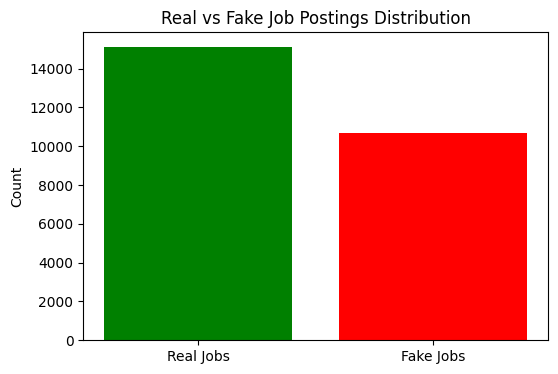

In [10]:
import matplotlib.pyplot as plt

counts = df_clean['fraudulent'].value_counts()
real = counts[0]
fake = counts[1]

print("🧾 Dataset Balance Summary")
print(f"Total samples: {len(df_clean)}")
print(f"Real (0): {real}")
print(f"Fake (1): {fake}")
print(f"Fake %: {round(fake / len(df_clean) * 100, 2)}%")

plt.figure(figsize=(6,4))
plt.bar(['Real Jobs', 'Fake Jobs'], [real, fake], color=['green', 'red'])
plt.title('Real vs Fake Job Postings Distribution')
plt.ylabel('Count')
plt.show()


In [11]:
from sklearn.utils import resample

df_real = df_clean[df_clean['fraudulent'] == 0]
df_fake = df_clean[df_clean['fraudulent'] == 1]

df_fake_up = resample(df_fake, replace=True, n_samples=len(df_real), random_state=42)
df_balanced = pd.concat([df_real, df_fake_up]).sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Balanced dataset created")
print(df_balanced['fraudulent'].value_counts())
print(df_balanced['fraudulent'].value_counts(normalize=True) * 100)
print("Total samples:", len(df_balanced))


✅ Balanced dataset created
fraudulent
1    15113
0    15113
Name: count, dtype: int64
fraudulent
1    50.0
0    50.0
Name: proportion, dtype: float64
Total samples: 30226



📊 Model Evaluation Report (After Enrichment):
              precision    recall  f1-score   support

           0      0.968     1.000     0.984      3023
           1      1.000     0.967     0.983      3023

    accuracy                          0.983      6046
   macro avg      0.984     0.983     0.983      6046
weighted avg      0.984     0.983     0.983      6046

✅ Accuracy: 0.9835


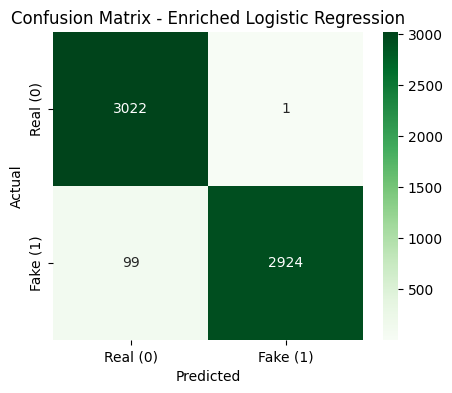

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
from scipy.sparse import hstack

# Suspicious keywords
suspicious_keywords = [
    'earn','money','income','cash','hurry','limited','urgent','apply now','no experience',
    'work from home','easy job','quick money','investment','bitcoin','crypto','telegram',
    'whatsapp','pay to apply','registration fee','send details','bank account','click here','link'
]

def suspicious_feature(text):
    text = text.lower()
    return sum(word in text for word in suspicious_keywords)

df_balanced['text_len'] = df_balanced['text'].apply(len)
df_balanced['num_suspicious'] = df_balanced['text'].apply(suspicious_feature)
df_balanced['text_len'] = np.log1p(df_balanced['text_len'])

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text'], df_balanced['fraudulent'],
    test_size=0.2, random_state=42, stratify=df_balanced['fraudulent']
)

vectorizer = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

train_extra = df_balanced.loc[X_train.index, ['text_len','num_suspicious']].to_numpy()
test_extra = df_balanced.loc[X_test.index, ['text_len','num_suspicious']].to_numpy()

X_train_final = hstack([X_train_tfidf, train_extra])
X_test_final = hstack([X_test_tfidf, test_extra])

model_enriched = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
model_enriched.fit(X_train_final, y_train)

y_pred = model_enriched.predict(X_test_final)

print("\n📊 Model Evaluation Report (After Enrichment):")
print(classification_report(y_test, y_pred, digits=3))
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real (0)','Fake (1)'], yticklabels=['Real (0)','Fake (1)'])
plt.title('Confusion Matrix - Enriched Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [13]:
# === Cell 7: Test the enriched model on real/fake examples ===
def predict_job_posting_enriched(text):
    import numpy as np
    
    # Clean input
    text_clean = " ".join(text.lower().split())

    # TF-IDF transform
    X_input_tfidf = vectorizer.transform([text_clean])
    
    # Extra features
    text_len = np.log1p(len(text_clean))
    num_suspicious = sum(word in text_clean for word in [
        'earn', 'money', 'income', 'cash', 'hurry', 'limited', 'urgent',
        'apply now', 'no experience', 'work from home', 'easy job', 'quick money',
        'investment', 'bitcoin', 'crypto', 'telegram', 'whatsapp', 'pay to apply',
        'registration fee', 'send details', 'bank account', 'click here', 'link'
    ])
    
    X_extra = np.array([[text_len, num_suspicious]])
    
    # Combine TF-IDF + numeric features
    from scipy.sparse import hstack
    X_input_final = hstack([X_input_tfidf, X_extra])
    
    # Predict
    pred = model_enriched.predict(X_input_final)[0]
    proba = model_enriched.predict_proba(X_input_final)[0]
    
    label = "🟥 FAKE JOB POSTING" if pred == 1 else "🟩 REAL JOB POSTING"
    confidence = round(float(np.max(proba)) * 100, 2)
    
    print(f"\nPrediction: {label}")
    print(f"Confidence: {confidence}%")
    print(f"→ Real (0): {proba[0]:.4f} | Fake (1): {proba[1]:.4f}")
    print("-" * 50)

# 🔹 Example 1: Real job
text_real = """
We are looking for a Data Analyst to join our growing analytics team in Hyderabad.
Candidates should have strong SQL, Excel, and Python skills.
Competitive salary, health insurance, and hybrid work options provided.
"""
predict_job_posting_enriched(text_real)

# 🔹 Example 2: Fake job
text_fake = """
Earn $5000 per week easily by working from home! No experience required.
Just send your personal details and start earning immediately. Limited seats!
"""
predict_job_posting_enriched(text_fake)

# 🔹 Example 3: Another fake posting
text_fake2 = """
Work from home online typing job. Pay to register and start earning daily.
Send your bank account details and we will activate your account instantly.
"""
predict_job_posting_enriched(text_fake2)



Prediction: 🟩 REAL JOB POSTING
Confidence: 95.19%
→ Real (0): 0.9519 | Fake (1): 0.0481
--------------------------------------------------

Prediction: 🟥 FAKE JOB POSTING
Confidence: 82.38%
→ Real (0): 0.1762 | Fake (1): 0.8238
--------------------------------------------------

Prediction: 🟥 FAKE JOB POSTING
Confidence: 72.12%
→ Real (0): 0.2788 | Fake (1): 0.7212
--------------------------------------------------


In [14]:
# === Cell 8: Test job posting mentioning Gmail contact ===

# Example 1: Legit job with a company domain email (real)
text_real_email = """
We are hiring a Machine Learning Engineer for our Hyderabad office.
Experience in TensorFlow, Python, and NLP preferred.
Send your CV to careers@techfusion.ai with the subject line 'ML Engineer Application'.
"""
predict_job_posting_enriched(text_real_email)

# Example 2: Suspicious job asking to contact a Gmail (fake)
text_fake_email = """
Work from home data entry job! Earn up to $4000 monthly.
No experience needed. Just send your resume to jobsfree2024@gmail.com to get started.
Limited openings available!
"""
predict_job_posting_enriched(text_fake_email)

# Example 3: Another tricky one (semi-fake)
text_fake2_email = """
We are urgently hiring for a remote marketing assistant.
Apply now by sending your details to marketingrecruiters@gmail.com.
No previous experience required, full training provided.
"""
predict_job_posting_enriched(text_fake2_email)



Prediction: 🟩 REAL JOB POSTING
Confidence: 69.54%
→ Real (0): 0.6954 | Fake (1): 0.3046
--------------------------------------------------

Prediction: 🟥 FAKE JOB POSTING
Confidence: 93.42%
→ Real (0): 0.0658 | Fake (1): 0.9342
--------------------------------------------------

Prediction: 🟥 FAKE JOB POSTING
Confidence: 52.31%
→ Real (0): 0.4769 | Fake (1): 0.5231
--------------------------------------------------


In [15]:
# === Cell 9: Save Logistic Regression Model and Vectorizer ===
import joblib
import os

# Create a folder to store artifacts
os.makedirs("saved_models", exist_ok=True)

# Save model and vectorizer
joblib.dump(model_enriched, "saved_models/fake_job_detector_model_logestic.pkl")
joblib.dump(vectorizer, "saved_models/tfidf_vectorizer_logestic.pkl")

print("✅ Model and vectorizer saved successfully!")

# Confirm files
print("\nSaved files:")
for f in os.listdir("saved_models"):
    print("📁", f)


✅ Model and vectorizer saved successfully!

Saved files:
📁 fake_job_detector_model_logestic.pkl
📁 tfidf_vectorizer_logestic.pkl


In [16]:
import numpy as np
from scipy.sparse import hstack
import re
import joblib

# Load model + vectorizer
model_loaded = joblib.load("/kaggle/working/saved_models/fake_job_detector_model_logestic.pkl")
vectorizer_loaded = joblib.load("/kaggle/working/saved_models/tfidf_vectorizer_logestic.pkl")

# Suspicious keywords list (same as training)
suspicious_keywords = [
    'earn', 'money', 'income', 'cash', 'hurry', 'limited', 'urgent',
    'apply now', 'no experience', 'work from home', 'easy job', 'quick money',
    'investment', 'bitcoin', 'crypto', 'telegram', 'whatsapp', 'pay to apply',
    'registration fee', 'send details', 'bank account', 'click here', 'link'
]

def predict_job_posting_loaded(text):
    """Predict using the saved logistic model with numeric features."""
    text_clean = re.sub(r'\s+', ' ', text.lower().strip())
    
    # TF-IDF transformation
    X_tfidf = vectorizer_loaded.transform([text_clean])
    
    # Create the 2 additional numeric features
    text_len = np.log1p(len(text_clean))
    num_suspicious = sum(word in text_clean for word in suspicious_keywords)
    X_extra = np.array([[text_len, num_suspicious]])
    
    # Combine both
    X_final = hstack([X_tfidf, X_extra])
    
    # Predict
    pred = model_loaded.predict(X_final)[0]
    proba = model_loaded.predict_proba(X_final)[0]
    
    label = "🟥 FAKE JOB POSTING" if pred == 1 else "🟩 REAL JOB POSTING"
    print(f"\nPrediction: {label}")
    print(f"→ Real (0): {proba[0]:.4f} | Fake (1): {proba[1]:.4f}")
    print(f"Confidence: {round(np.max(proba)*100, 2)}%")

# Example test
text = "Work from home, earn $3000 weekly without experience. Send your details now!"
predict_job_posting_loaded(text)



Prediction: 🟥 FAKE JOB POSTING
→ Real (0): 0.1431 | Fake (1): 0.8569
Confidence: 85.69%
